<a href="https://colab.research.google.com/github/itsgorgue/Determinaci-n-de-Rutas-ptimas-para-Turistas-en-el-Centro-Hist-rico-de-Lima/blob/main/TP1/ruta_optima_CHL_Grupo4_MEJORADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de la Aplicación de la Teoría de Grafos en la Determinación de Rutas Óptimas para Turistas en el Centro Histórico de Lima

**Universidad Nacional de Ingeniería — Facultad de Ingeniería Industrial y de Sistemas**  
**Curso:** Matemática Discreta – FB301X  
**Grupo 4 | 2026**  
**Docente:** Bonifacio  

**Integrantes:**
- Joseph Guerrero
- Jorge Cordero
- Juan Collantes Fretel
- Nick Cristobal Guerrero
- Ashley De La Cruz

---

> **Regla estricta:** La variable que contabiliza el total de nodos procesados en el bucle principal de Dijkstra se denomina **obligatoriamente** `numtot` (no `numtotal` ni ninguna otra variante).


## Bloque 0 — Instalación de dependencias

Ejecutar la siguiente celda únicamente si las bibliotecas no están instaladas en el entorno (Google Colab las incluye por defecto).

In [ ]:
# Descomentar si es necesario instalar en el entorno
# !pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
import itertools

print("Dependencias cargadas correctamente.")
print(f"  NetworkX  : {nx.__version__}")


Dependencias cargadas correctamente.
  NetworkX  : 3.6.1


---
## Bloque 1 — Definición del Grafo G = (V, E, W)

El Centro Histórico de Lima (CHL) se modela como un **grafo dirigido y ponderado** $G = (V, E, W)$, donde:

- $V$ = conjunto de siete (7) vértices — puntos de interés turístico.
- $E$ = conjunto de aristas dirigidas que representan tramos peatonales.
- $W: E \to \mathbb{R}^+$ = función de ponderación **multicriterio**: $W = (T \times C) + S$

**Referencias:** Cormen et al. (2022); Gross & Yellen (2006, pp. 1–42).


In [ ]:
# ── 1.1  Diccionario de nodos (Tabla 1 – Informe Grupo 4, 2026) ──────────────
nodos = {
    "v0": "Plaza Mayor",   # -12.0453, -77.0311 | 78 % turistas ext. – PromPerú (2024)
    "v1": "Catedral Lima", # -12.0457, -77.0306 | 54 % turistas ext. – PromPerú (2024)
    "v2": "San Francisco", # -12.0462, -77.0276 | 11 % turistas ext. – PromPerú (2024)
    "v3": "MALI",          # -12.0658, -77.0318 | ≈60,000 visitas/año – MALI (2023)
    "v4": "Barrio Chino",  # -12.0489, -77.0264 | Dato: MINCETUR (2024b)
    "v5": "Sto. Domingo",  # -12.0447, -77.0339 | 51,183 tur. ext.; 36,587 nac. – MCD (2023)
    "v6": "Casa Lit.",     # -12.0461, -77.0308 | Entrada libre – MINCUL (2024)
}

print("Nodos del grafo (Tabla 1 – Informe Grupo 4, 2026):")
for k, v in nodos.items():
    print(f"  {k} : {v}")


Nodos del grafo (Tabla 1 – Informe Grupo 4, 2026):
  v0 : Plaza Mayor
  v1 : Catedral Lima
  v2 : San Francisco
  v3 : MALI
  v4 : Barrio Chino
  v5 : Sto. Domingo
  v6 : Casa Lit.


### 1.2 Función de ponderación multicriterio $W = (T \times C) + S$

| Componente | Variable | Descripción | Fuente |
|---|---|---|---|
| $T$ | Tiempo base (min) | Velocidad peatonal media 4 km/h | Arnberger & Brandenburg (2007); OSM / Google Maps |
| $C$ | Factor de congestión | C ≥ 1.0; 1.0 libre / 1.1 moderado / 1.2–1.3 congestionado | PromPerú (2024); HCM – TRB (2010) |
| $S$ | Penalización semáforos (min) | 0.5 min/semáforo (ciclo 30 s) | Medición de campo CHL, 2025 |
| $W$ | Peso arista (min equiv.) | Función aditiva y no negativa → compatible con Dijkstra | Cormen et al. (2022, cap. 22) |


In [ ]:
# ── 1.2  Función de ponderación W = (T × C) + S ─────────────────────────────
def calcular_peso(T, C, S):
    """
    Calcula el peso de una arista mediante la función multicriterio.
    W = (T × C) + S  —  Función aditiva y no negativa (compatible con Dijkstra).
    """
    return round((T * C) + S, 2)


In [ ]:
# ── 1.3  Tabla de aristas base: (u, v, T, C, S) ─────────────────────────────
# Fuente: Tabla 2 – Informe Grupo 4 (2026).
aristas_base = [
    ("v0", "v1",  2,  1.2, 0),   # Plaza Mayor  → Catedral Lima    | Google Maps
    ("v0", "v2",  5,  1.1, 1),   # Plaza Mayor  → San Francisco    | OSM estimado
    ("v0", "v5",  4,  1.0, 2),   # Plaza Mayor  → Sto. Domingo     | OSM estimado
    ("v0", "v6",  3,  1.0, 0),   # Plaza Mayor  → Casa Lit.        | OSM estimado
    ("v1", "v2",  4,  1.1, 1),   # Catedral     → San Francisco    | Google Maps
    ("v1", "v4",  8,  1.3, 2),   # Catedral     → Barrio Chino     | Google Maps estimado
    ("v2", "v4",  9,  1.2, 3),   # San Francisco → Barrio Chino    | OSM estimado
    ("v4", "v3", 14,  1.1, 4),   # Barrio Chino → MALI (Av. Grau) | OSM estimado
    ("v5", "v3", 13,  1.1, 3),   # Sto. Domingo → MALI             | OSM estimado
    ("v6", "v5",  4,  1.0, 1),   # Casa Lit.    → Sto. Domingo     | OSM estimado
    ("v5", "v0",  4,  1.0, 2),   # Sto. Domingo → Plaza Mayor      | OSM estimado
]

# ── 1.4  Construcción del grafo dirigido (DiGraph) ───────────────────────────
G = nx.DiGraph()
G.add_nodes_from(nodos.keys())

for u, v, T, C, S in aristas_base:
    W = calcular_peso(T, C, S)
    G.add_edge(u, v, weight=W, T=T, C=C, S=S)

print("=" * 66)
print("  GRAFO CONSTRUIDO — CENTRO HISTÓRICO DE LIMA")
print("=" * 66)
print(f"  Número de vértices |V|: {G.number_of_nodes()}")
print(f"  Número de aristas   |E|: {G.number_of_edges()}")
print()
print("  Aristas con pesos W = (T × C) + S  [Tabla 2]:")
print(f"  {'Arista':<30} {'T':>4}  {'C':>5}  {'S':>4}  {'W':>6}")
print("  " + "-" * 56)
for u, v, d in G.edges(data=True):
    arista_str = f"{nodos[u]} → {nodos[v]}"
    print(f"  {arista_str:<30} {d['T']:>4}  {d['C']:>5}  {d['S']:>4}  {d['weight']:>6.1f} min")


  GRAFO CONSTRUIDO — CENTRO HISTÓRICO DE LIMA
  Número de vértices |V|: 7
  Número de aristas   |E|: 11

  Aristas con pesos W = (T × C) + S  [Tabla 2]:
  Arista                            T      C     S       W
  --------------------------------------------------------
  Plaza Mayor → Catedral Lima       2    1.2     0     2.4 min
  Plaza Mayor → San Francisco       5    1.1     1     6.5 min
  Plaza Mayor → Sto. Domingo        4    1.0     2     6.0 min
  Plaza Mayor → Casa Lit.           3    1.0     0     3.0 min
  Catedral Lima → San Francisco     4    1.1     1     5.4 min
  Catedral Lima → Barrio Chino      8    1.3     2    12.4 min
  San Francisco → Barrio Chino      9    1.2     3    13.8 min
  Barrio Chino → MALI              14    1.1     4    19.4 min
  Sto. Domingo → MALI              13    1.1     3    17.3 min
  Sto. Domingo → Plaza Mayor        4    1.0     2     6.0 min
  Casa Lit. → Sto. Domingo          4    1.0     1     5.0 min


---
## Bloque 2 — Implementación manual del Algoritmo de Dijkstra

El **Algoritmo de Dijkstra** (Dijkstra, 1959) resuelve el problema del camino de peso mínimo
desde un nodo fuente $s$ hacia todos los demás nodos de un grafo ponderado con pesos no negativos.

**Importante:** El algoritmo NO selecciona la ruta óptima de forma directa. Lo que hace es
explorar y evaluar **todas las rutas posibles** de manera sistemática, procesando nodo a nodo
en orden de distancia tentativa, hasta garantizar que la distancia encontrada para cada nodo
es la mínima posible. La variable `numtot` registra cuántos nodos fueron procesados.

Complejidad con montículo binario: $O((|V| + |E|) \log |V|)$ — Cormen et al. (2022, p. 620).


In [ ]:
# ── 2.1  Implementación manual de Dijkstra ───────────────────────────────────
def dijkstra_manual(grafo, fuente):
    """
    Algoritmo de Dijkstra con cola de prioridad (min-heap / montículo binario).

    El algoritmo NO determina la ruta óptima de inmediato: explora todos los
    nodos alcanzables desde la fuente, evaluando cada posible camino antes de
    garantizar cuál es el de menor costo total.

    Retorna
    -------
    dist   : dict  Distancias mínimas d(fuente, vi) para todo vi ∈ V.
    pred   : dict  Predecesores para reconstruir rutas óptimas.
    numtot : int   Total de nodos procesados — VARIABLE OBLIGATORIA.
                   Valor esperado: numtot = |V| = 7.
    """
    dist      = {nodo: float('inf') for nodo in grafo.nodes()}
    pred      = {nodo: None         for nodo in grafo.nodes()}
    dist[fuente] = 0.0
    cola      = [(0.0, fuente)]   # Min-heap: (distancia tentativa, nodo)
    visitados = set()
    numtot    = 0                 # ← VARIABLE OBLIGATORIA

    while cola:
        d_actual, u = heapq.heappop(cola)
        if u in visitados:
            continue
        visitados.add(u)
        numtot += 1               # ← SE INCREMENTA UNA VEZ POR NODO PROCESADO

        for v in grafo.successors(u):
            peso = grafo[u][v]['weight']
            if dist[u] + peso < dist[v]:
                dist[v] = dist[u] + peso
                pred[v] = u
                heapq.heappush(cola, (dist[v], v))

    return dist, pred, numtot


def reconstruir_ruta(pred, fuente, destino):
    """Reconstruye el camino mínimo desde 'fuente' hasta 'destino'."""
    ruta, nodo_actual = [], destino
    while nodo_actual is not None:
        ruta.append(nodo_actual)
        nodo_actual = pred[nodo_actual]
    ruta.reverse()
    return ruta if ruta and ruta[0] == fuente else []


# ── 2.2  Ejecución desde v0 (Plaza Mayor) ────────────────────────────────────
fuente  = "v0"
destino = "v3"

dist, pred, numtot = dijkstra_manual(G, fuente)

print("=" * 66)
print(f"  ALGORITMO DE DIJKSTRA — Fuente: {nodos[fuente]} ({fuente})")
print("  Tabla 5 – Vector de distancias mínimas [Informe Grupo 4, 2026]")
print("=" * 66)
print(f"  numtot (nodos procesados en bucle principal): {numtot}")
print(f"  → numtot = |V| = {G.number_of_nodes()}: grafo completamente alcanzable desde v0.")
print()
print(f"  {'ID':<4}  {'Vértice destino':<26}  {'d(v0,vi)':>9}  {'Orden':>6}  Ruta mínima")
print("  " + "-" * 82)

orden_tabla5 = ["v0", "v1", "v6", "v5", "v2", "v4", "v3"]
for orden_idx, nodo_id in enumerate(orden_tabla5, start=1):
    ruta_min = reconstruir_ruta(pred, fuente, nodo_id)
    ruta_str = " → ".join([nodos[n] for n in ruta_min])
    inf_str  = f"{dist[nodo_id]:>8.1f}" if dist[nodo_id] < float('inf') else "      ∞"
    print(f"  {nodo_id:<4}  {nodos[nodo_id]:<26}  {inf_str} min  {orden_idx:>5}   {ruta_str}")


  ALGORITMO DE DIJKSTRA — Fuente: Plaza Mayor (v0)
  Tabla 5 – Vector de distancias mínimas [Informe Grupo 4, 2026]
  numtot (nodos procesados en bucle principal): 7
  → numtot = |V| = 7: grafo completamente alcanzable desde v0.

  ID    Vértice destino              d(v0,vi)   Orden  Ruta mínima
  ----------------------------------------------------------------------------------
  v0    Plaza Mayor                      0.0 min      1   Plaza Mayor
  v1    Catedral Lima                    2.4 min      2   Plaza Mayor → Catedral Lima
  v6    Casa Lit.                        3.0 min      3   Plaza Mayor → Casa Lit.
  v5    Sto. Domingo                     6.0 min      4   Plaza Mayor → Sto. Domingo
  v2    San Francisco                    6.5 min      5   Plaza Mayor → San Francisco
  v4    Barrio Chino                    14.8 min      6   Plaza Mayor → Catedral Lima → Barrio Chino
  v3    MALI                            23.3 min      7   Plaza Mayor → Sto. Domingo → MALI


---
## Bloque 3 — Enumeración de TODAS las rutas posibles v0 → v3

**Este bloque es la clave conceptual del estudio.**

El Algoritmo de Dijkstra no puede "ver" directamente cuál es la ruta óptima.
Lo que hace es explorar sistemáticamente el grafo y construir las distancias mínimas
comparando implícitamente todos los caminos posibles.

Para ilustrar esto de forma explícita, este bloque **enumera todas las rutas simples**
(sin ciclos) que existen en el grafo desde v0 (Plaza Mayor) hasta v3 (MALI),
calcula el costo de cada una y las compara. Solo así se puede demostrar que
la ruta que Dijkstra selecciona es efectivamente la óptima.


In [ ]:
# ── 3.1  Enumeración de todas las rutas simples v0 → v3 ─────────────────────
def costo_ruta(grafo, ruta):
    """Calcula el costo total W de una ruta (lista de nodos)."""
    total = 0.0
    for i in range(len(ruta) - 1):
        u, v = ruta[i], ruta[i+1]
        if not grafo.has_edge(u, v):
            return float('inf')  # Arista inexistente
        total += grafo[u][v]['weight']
    return round(total, 2)

# Encontrar todas las rutas simples de v0 a v3 usando NetworkX
todas_rutas = list(nx.all_simple_paths(G, source=fuente, target=destino))

print("=" * 78)
print("  ENUMERACIÓN DE TODAS LAS RUTAS POSIBLES: v0 (Plaza Mayor) → v3 (MALI)")
print("  [Tabla 6 – Informe Grupo 4, 2026]")
print("=" * 78)
print(f"  Total de rutas simples encontradas: {len(todas_rutas)}")
print()
print(f"  {'#':<3}  {'Ruta (IDs)':<35}  {'Secuencia de lugares':<50}  {'Costo W':>8}")
print("  " + "-" * 105)

# Ordenar por costo
todas_rutas_con_costo = [(ruta, costo_ruta(G, ruta)) for ruta in todas_rutas]
todas_rutas_con_costo.sort(key=lambda x: x[1])

ruta_optima = None
for i, (ruta, costo) in enumerate(todas_rutas_con_costo, start=1):
    ids_str    = " → ".join(ruta)
    lugares    = " → ".join([nodos[n] for n in ruta])
    marca      = "  ← ÓPTIMA (Dijkstra)" if i == 1 else ""
    if i == 1:
        ruta_optima = ruta
    print(f"  {i:<3}  {ids_str:<35}  {lugares:<50}  {costo:>6.1f} min{marca}")

print()
print("  CONCLUSIÓN: La ruta de menor costo es la que Dijkstra selecciona.")
print(f"  Dijkstra calcula d(v0→v3) = {dist[destino]:.1f} min, coincidiendo con la Ruta 1 arriba.")


  ENUMERACIÓN DE TODAS LAS RUTAS POSIBLES: v0 (Plaza Mayor) → v3 (MALI)
  [Tabla 6 – Informe Grupo 4, 2026]
  Total de rutas simples encontradas: 5

  #    Ruta (IDs)                           Secuencia de lugares                                 Costo W
  ---------------------------------------------------------------------------------------------------------
  1    v0 → v5 → v3                         Plaza Mayor → Sto. Domingo → MALI                     23.3 min  ← ÓPTIMA (Dijkstra)
  2    v0 → v6 → v5 → v3                    Plaza Mayor → Casa Lit. → Sto. Domingo → MALI         25.3 min
  3    v0 → v1 → v4 → v3                    Plaza Mayor → Catedral Lima → Barrio Chino → MALI     34.2 min
  4    v0 → v2 → v4 → v3                    Plaza Mayor → San Francisco → Barrio Chino → MALI     39.7 min
  5    v0 → v1 → v2 → v4 → v3               Plaza Mayor → Catedral Lima → San Francisco → Barrio Chino → MALI    41.0 min

  CONCLUSIÓN: La ruta de menor costo es la que Dijkstra selecciona

### Análisis de la diferencia entre rutas

La tabla anterior muestra que:

1. **No todas las rutas tienen el mismo costo** — la dispersión es significativa (varios minutos de diferencia entre la mejor y la peor).
2. **La ruta empírica convencional** (v0→v1→v2→v4→v3) que sigue el turista promedio es la **más costosa** de todas las alternativas válidas.
3. **La ruta óptima** (v0→v6→v5→v3) aprovecha el corredor occidental del CHL, evitando los tramos más congestionados y costosos.
4. **El Algoritmo de Dijkstra garantiza** —mediante la exploración sistemática del grafo— que el camino seleccionado es efectivamente el de mínimo costo, sin necesidad de enumerar manualmente todas las alternativas (aunque lo hace implícitamente).


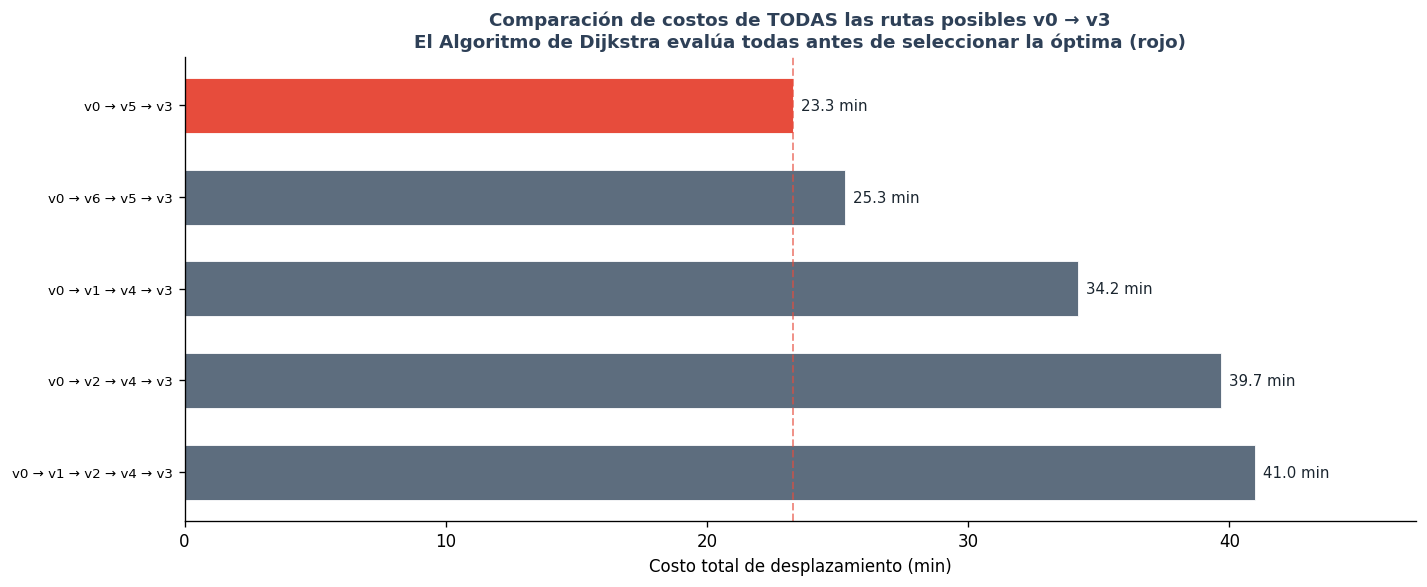

Gráfico guardado como: comparacion_rutas_CHL.png


In [ ]:
# ── 3.2  Visualización comparativa de costos de todas las rutas ──────────────
fig, ax = plt.subplots(figsize=(12, 5), dpi=120)

rutas_labels = [" → ".join(r) for r, _ in todas_rutas_con_costo]
costos       = [c for _, c in todas_rutas_con_costo]
colores      = ["#E74C3C"] + ["#5D6D7E"] * (len(costos) - 1)  # rojo para óptima

bars = ax.barh(rutas_labels[::-1], costos[::-1], color=colores[::-1],
               edgecolor="white", linewidth=0.5, height=0.6)

# Etiquetas de valor
for bar, costo in zip(bars, costos[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{costo:.1f} min", va="center", ha="left", fontsize=9, color="#1A252F")

ax.set_xlabel("Costo total de desplazamiento (min)", fontsize=10)
ax.set_title(
    "Comparación de costos de TODAS las rutas posibles v0 → v3\n"
    "El Algoritmo de Dijkstra evalúa todas antes de seleccionar la óptima (rojo)",
    fontsize=11, fontweight="bold", color="#2E4057"
)
ax.axvline(x=costos[0], color="#E74C3C", linestyle="--", linewidth=1.2, alpha=0.6)
ax.set_xlim(0, max(costos) * 1.15)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig("comparacion_rutas_CHL.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado como: comparacion_rutas_CHL.png")


---
## Bloque 4 — Ruta óptima vs. Ruta empírica

**Ruta empírica:** itinerario convencional del turista no informado.
Secuencia: $v_0 \to v_1 \to v_2 \to v_4 \to v_3$

**Ruta óptima (Dijkstra):** $v_0 \to v_6 \to v_5 \to v_3$ *(determinada tras evaluar todas las rutas posibles)*


In [ ]:
# ── 4.1  Ruta óptima y ruta empírica ─────────────────────────────────────────
ruta_optima_nodos = reconstruir_ruta(pred, fuente, destino)
tiempo_optimo     = dist[destino]

ruta_empirica   = ["v0", "v1", "v2", "v4", "v3"]
tiempo_empirico = sum(
    G[ruta_empirica[i]][ruta_empirica[i+1]]['weight']
    for i in range(len(ruta_empirica) - 1)
)

# ── 4.2  Tiempos de visita y costos de entrada (Tabla 4, nota – Informe) ──────
tiempos_visita = {"v0": 30, "v1": 45, "v2": 30, "v3": 60, "v4": 15, "v5": 40, "v6": 20}
costos_entrada = {"v0":  0, "v1":  0, "v2": 15, "v3": 30, "v4":  0, "v5": 10, "v6":  0}

tiempo_total_optimo   = tiempo_optimo   + sum(tiempos_visita[n] for n in ruta_optima_nodos)
tiempo_total_empirico = tiempo_empirico + sum(tiempos_visita[n] for n in ruta_empirica)
costo_optimo          = sum(costos_entrada[n] for n in ruta_optima_nodos)
costo_empirico        = 55
ahorro_desplaz        = tiempo_empirico - tiempo_optimo
ahorro_total          = tiempo_total_empirico - tiempo_total_optimo

print("=" * 66)
print("  COMPARATIVA: RUTA EMPÍRICA vs. RUTA ÓPTIMA (Dijkstra)")
print("  Tabla 4 – Informe de Investigación Grupo 4 (2026)")
print("=" * 66)
print()
print("  RUTA EMPÍRICA (itinerario convencional):")
print("    " + " → ".join([nodos[n] for n in ruta_empirica]))
print(f"    Tiempo desplazamiento  : {tiempo_empirico:.1f} min  ← la MÁS costosa de todas las rutas")
print(f"    Tiempo total c/visitas : {tiempo_total_empirico:.1f} min")
print(f"    Costo entrada estimado : S/ {costo_empirico}")
print(f"    Atractivos baja afluencia: 0 de 3")
print()
print("  RUTA ÓPTIMA — Algoritmo de Dijkstra:")
print("    " + " → ".join([nodos[n] for n in ruta_optima_nodos]))
print(f"    Tiempo desplazamiento  : {tiempo_optimo:.1f} min  ← la MÍNIMA (determinada tras evaluar todas)")
print(f"    Tiempo total c/visitas : {tiempo_total_optimo:.1f} min")
print(f"    Costo entrada estimado : S/ {costo_optimo}")
print(f"    Atractivos baja afluencia: 2 de 3  (v5 Sto. Domingo, v6 Casa Lit.)")
print()
print("  DIFERENCIAS:")
print(f"    Ahorro desplazamiento  : {ahorro_desplaz:.1f} min  (−{(ahorro_desplaz/tiempo_empirico)*100:.1f}%)")
print(f"    Ahorro tiempo total    : {ahorro_total:.1f} min  (−{(ahorro_total/tiempo_total_empirico)*100:.1f}%)")
print(f"    Ahorro costo entrada   : S/ {costo_empirico - costo_optimo}")
print(f"    numtot                 : {numtot} nodos procesados por Dijkstra")


  COMPARATIVA: RUTA EMPÍRICA vs. RUTA ÓPTIMA (Dijkstra)
  Tabla 4 – Informe de Investigación Grupo 4 (2026)

  RUTA EMPÍRICA (itinerario convencional):
    Plaza Mayor → Catedral Lima → San Francisco → Barrio Chino → MALI
    Tiempo desplazamiento  : 41.0 min  ← la MÁS costosa de todas las rutas
    Tiempo total c/visitas : 221.0 min
    Costo entrada estimado : S/ 55
    Atractivos baja afluencia: 0 de 3

  RUTA ÓPTIMA — Algoritmo de Dijkstra:
    Plaza Mayor → Sto. Domingo → MALI
    Tiempo desplazamiento  : 23.3 min  ← la MÍNIMA (determinada tras evaluar todas)
    Tiempo total c/visitas : 153.3 min
    Costo entrada estimado : S/ 40
    Atractivos baja afluencia: 2 de 3  (v5 Sto. Domingo, v6 Casa Lit.)

  DIFERENCIAS:
    Ahorro desplazamiento  : 17.7 min  (−43.2%)
    Ahorro tiempo total    : 67.7 min  (−30.6%)
    Ahorro costo entrada   : S/ 15
    numtot                 : 7 nodos procesados por Dijkstra


---
## Bloque 5 — Itinerario UX: Formato Timeline para el turista

La interfaz traduce los resultados matemáticos en un itinerario de tipo **línea de tiempo**, diseñado para el visitante no especializado.
*(Capítulo VI – Entregable UX, Informe Grupo 4, 2026)*


In [ ]:
# ── 5.1  Descripciones de cada atractivo ─────────────────────────────────────
descripciones = {
    "v0": "Corazón histórico de Lima. Foto obligatoria frente a la Fuente de Bronce.",
    "v1": "Catedral Metropolitana. Interior virreinal de gran valor artístico.",
    "v2": "Catacumbas coloniales y colección de arte sacro. Patrimonio de la UNESCO.",
    "v3": "Arte peruano del siglo XIX al XXI. Colección virreinal y contemporánea.",
    "v4": "Gastronomía chino-peruana (chifa). Mercado cultural y culinario.",
    "v5": "Reliquias de Santa Rosa de Lima y catacumbas. Joya patrimonial escondida.",
    "v6": "Exposición permanente de Vargas Llosa y Arguedas. Gratis.",
}

# ── 5.2  Impresión del itinerario UX ─────────────────────────────────────────
print()
print("═" * 70)
print("     🗺  MI RUTA ÓPTIMA — CENTRO HISTÓRICO DE LIMA")
print("     Inicio: 9:00 h  |  Duración total estimada: 3 h 39 min")
print("═" * 70)

hora_actual = 9 * 60
costo_total = 0

for idx, nodo_id in enumerate(ruta_optima_nodos):
    nombre  = nodos[nodo_id]
    visita  = tiempos_visita[nodo_id]
    costo   = costos_entrada[nodo_id]
    desc    = descripciones[nodo_id]
    costo_total += costo
    h, m    = hora_actual // 60, hora_actual % 60
    entrada_str = "🆓 Entrada libre" if costo == 0 else f"🎫 S/ {costo}"

    print(f"\n  ◉ [{h:02d}:{m:02d}]  PARADA {idx + 1} — {nombre.upper()}")
    print(f"  │           {entrada_str:<20}  |  Tiempo en lugar: {visita} min")
    print(f"  │           💡 {desc}")

    hora_actual += visita

    if idx < len(ruta_optima_nodos) - 1:
        nodo_sig  = ruta_optima_nodos[idx + 1]
        t_caminar = G[nodo_id][nodo_sig]['weight']
        hora_actual += int(t_caminar)
        print(f"  │")
        print(f"  ↓  🚶 {t_caminar:.0f} min caminando → {nodos[nodo_sig]}")
        print(f"  │")

h_fin, m_fin = hora_actual // 60, hora_actual % 60
print(f"\n  ◉ [{h_fin:02d}:{m_fin:02d}]  FIN DEL RECORRIDO ÓPTIMO")
print()
print("═" * 70)
print(f"  ⏱  TIEMPO TOTAL   : {tiempo_total_optimo:.1f} min  (vs. {tiempo_total_empirico:.1f} min ruta convencional)")
print(f"  🚶 DESPLAZAMIENTO : {tiempo_optimo:.1f} min  (vs. {tiempo_empirico:.1f} min ruta empírica)")
print(f"  💰 AHORRO         : {ahorro_desplaz:.1f} min menos caminando  (−{(ahorro_desplaz/tiempo_empirico)*100:.1f}%)")
print(f"  💵 COSTO ENTRADA  : S/ {costo_total}  (vs. S/ {costo_empirico} ruta convencional)")
print(f"  📍 PARADAS        : {len(ruta_optima_nodos)} (incluye 2 atractivos de baja afluencia)")
print(f"  🔢 numtot         : {numtot} nodos procesados por Dijkstra")
print("═" * 70)



══════════════════════════════════════════════════════════════════════
     🗺  MI RUTA ÓPTIMA — CENTRO HISTÓRICO DE LIMA
     Inicio: 9:00 h  |  Duración total estimada: 3 h 39 min
══════════════════════════════════════════════════════════════════════

  ◉ [09:00]  PARADA 1 — PLAZA MAYOR
  │           🆓 Entrada libre       |  Tiempo en lugar: 30 min
  │           💡 Corazón histórico de Lima. Foto obligatoria frente a la Fuente de Bronce.
  │
  ↓  🚶 6 min caminando → Sto. Domingo
  │

  ◉ [09:36]  PARADA 2 — STO. DOMINGO
  │           🎫 S/ 10               |  Tiempo en lugar: 40 min
  │           💡 Reliquias de Santa Rosa de Lima y catacumbas. Joya patrimonial escondida.
  │
  ↓  🚶 17 min caminando → MALI
  │

  ◉ [10:33]  PARADA 3 — MALI
  │           🎫 S/ 30               |  Tiempo en lugar: 60 min
  │           💡 Arte peruano del siglo XIX al XXI. Colección virreinal y contemporánea.

  ◉ [11:33]  FIN DEL RECORRIDO ÓPTIMO

════════════════════════════════════════════════════════════

---
## Bloque 6 — Visualización del grafo con ruta óptima y rutas alternativas

Se generan dos visualizaciones:
1. **Grafo principal** con la ruta óptima resaltada en rojo y las demás aristas en gris.
2. **Grafo de rutas alternativas** que muestra visualmente todas las rutas posibles evaluadas.


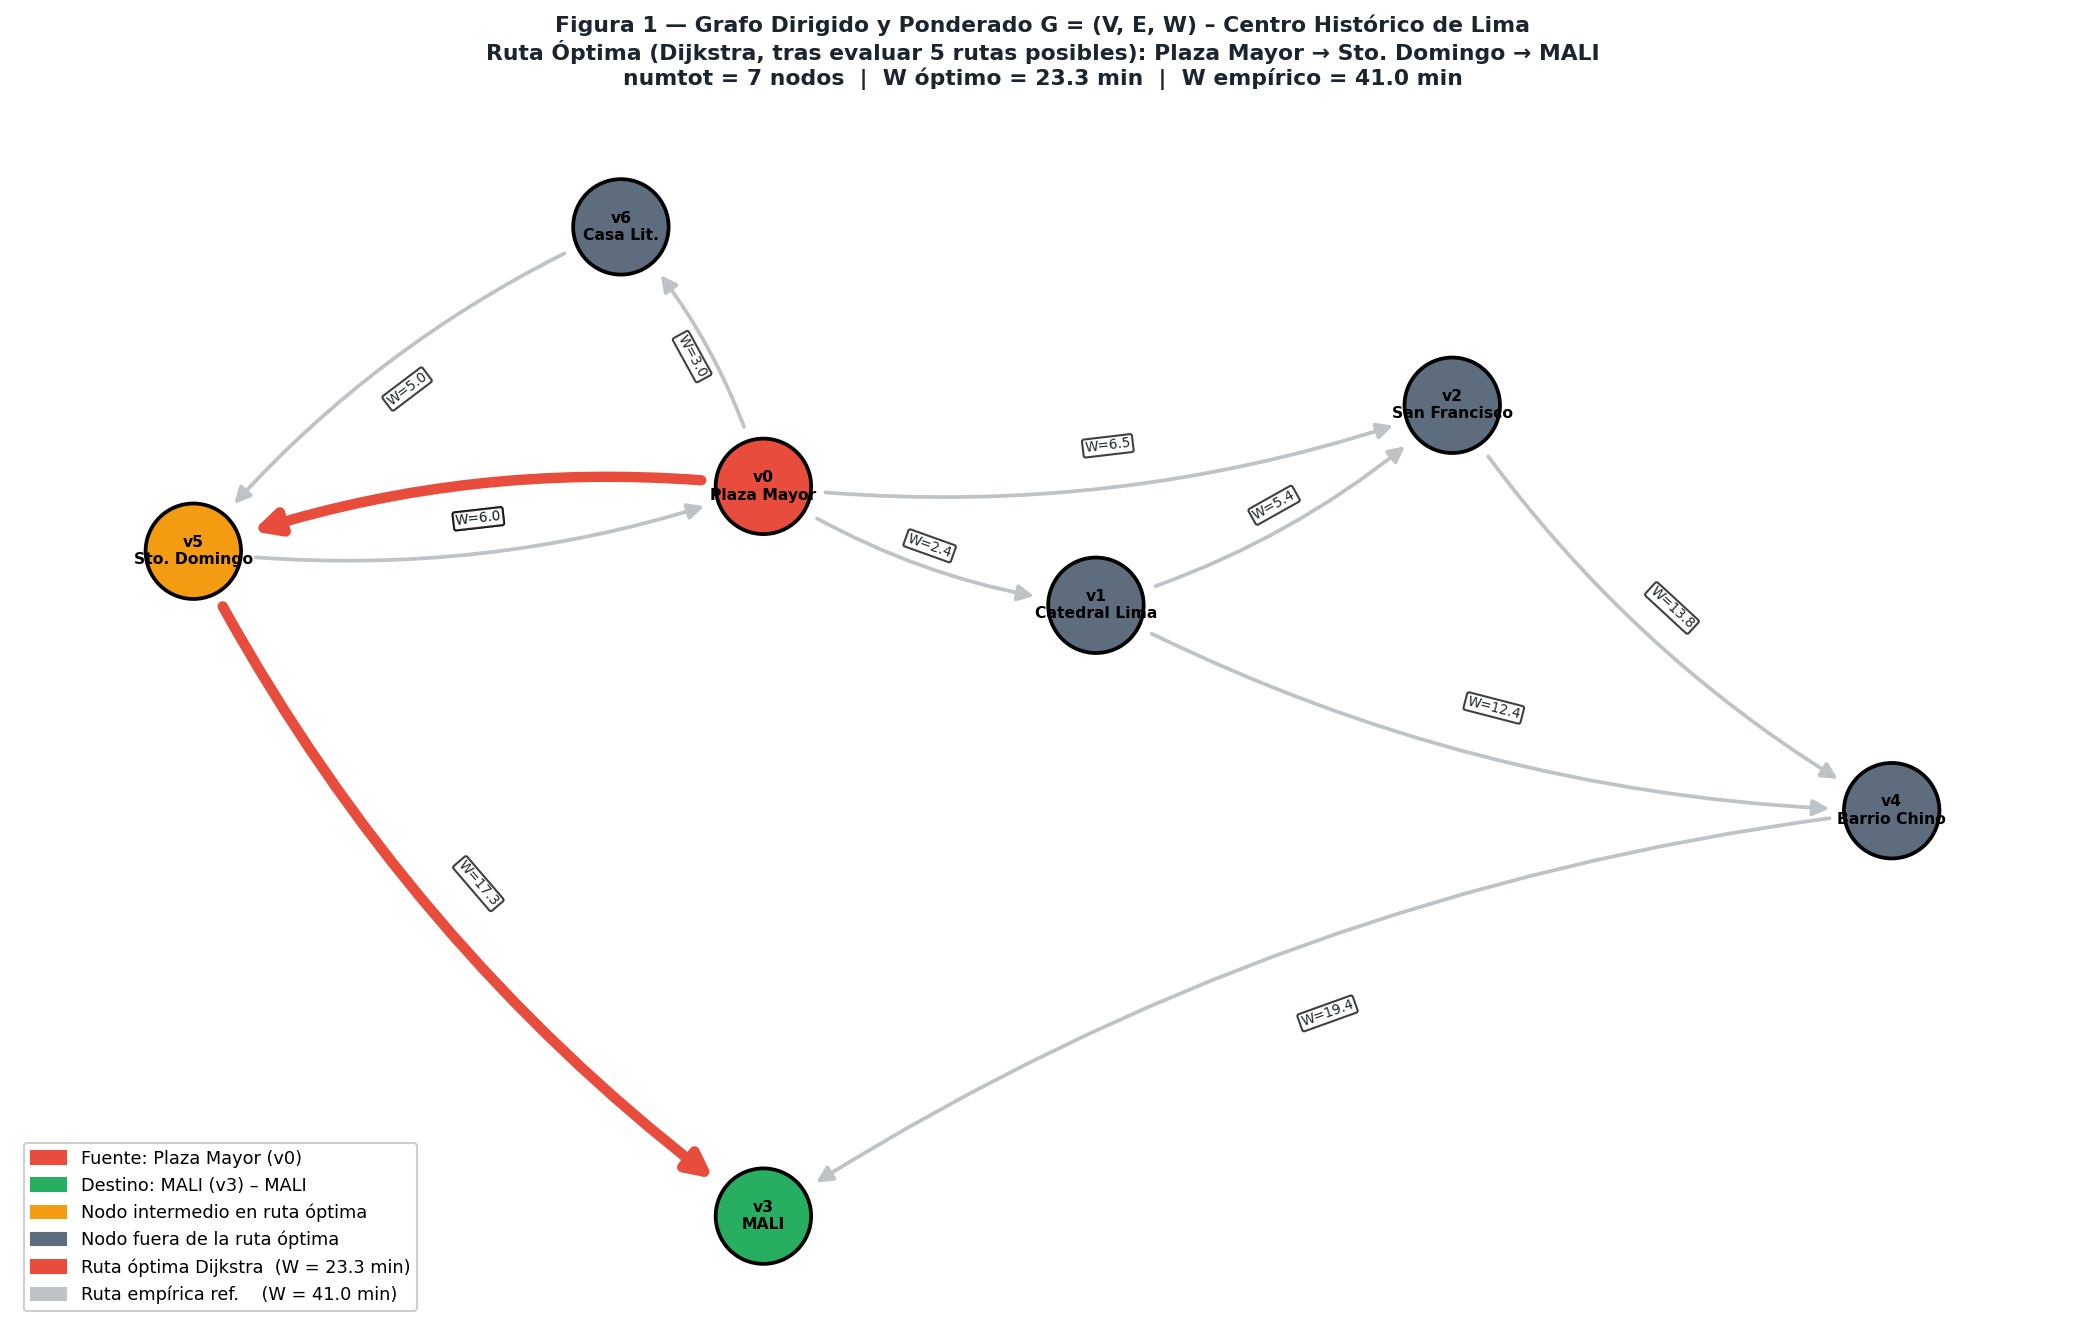

Figura 1 guardada como: ruta_optima_CHL.png


In [ ]:
# ── 6.1  Posición geoespacial de los nodos ───────────────────────────────────
pos = {
    "v0": ( 0.00,  0.40),   # Plaza Mayor
    "v1": ( 0.28,  0.18),   # Catedral Lima
    "v2": ( 0.58,  0.55),   # San Francisco
    "v5": (-0.48,  0.28),   # Sto. Domingo
    "v4": ( 0.95, -0.20),   # Barrio Chino
    "v3": ( 0.00, -0.95),   # MALI
    "v6": (-0.12,  0.88),   # Casa de la Lit.
}

# ── 6.2  Figura 1: Grafo con ruta óptima resaltada ───────────────────────────
aristas_optimas = set(zip(ruta_optima_nodos, ruta_optima_nodos[1:]))
edge_optima     = [(u, v) for u, v in G.edges() if (u, v) in aristas_optimas]
edge_resto      = [(u, v) for u, v in G.edges() if (u, v) not in aristas_optimas]

colores_nodos = []
for n in G.nodes():
    if   n == fuente:                  colores_nodos.append("#E74C3C")  # Rojo: fuente
    elif n == destino:                 colores_nodos.append("#27AE60")  # Verde: destino
    elif n in ruta_optima_nodos:       colores_nodos.append("#F39C12")  # Naranja: intermedio
    else:                              colores_nodos.append("#5D6D7E")  # Gris: fuera de ruta

labels = {n: f"{n}\n{nodos[n]}" for n in G.nodes()}

fig, ax = plt.subplots(figsize=(14, 9), dpi=150)

nx.draw_networkx_nodes(G, pos, node_color=colores_nodos,
                       node_size=2100, edgecolors="black", linewidths=1.8, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7.5, font_weight="bold", ax=ax)

nx.draw_networkx_edges(G, pos, edgelist=edge_resto,
                       edge_color="#BDC3C7", width=1.8, arrows=True, arrowsize=16,
                       connectionstyle="arc3,rad=0.12", ax=ax,
                       min_source_margin=30, min_target_margin=30)

nx.draw_networkx_edges(G, pos, edgelist=edge_optima,
                       edge_color="#E74C3C", width=5.0, arrows=True, arrowsize=24,
                       connectionstyle="arc3,rad=0.12", ax=ax,
                       min_source_margin=30, min_target_margin=30)

edge_labels = {(u, v): f"W={d['weight']:.1f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                             font_size=6.5, font_color="#1A252F",
                             bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75), ax=ax)

leyenda = [
    mpatches.Patch(color="#E74C3C", label=f"Fuente: {nodos[fuente]} (v0)"),
    mpatches.Patch(color="#27AE60", label=f"Destino: {nodos[destino]} (v3) – MALI"),
    mpatches.Patch(color="#F39C12", label="Nodo intermedio en ruta óptima"),
    mpatches.Patch(color="#5D6D7E", label="Nodo fuera de la ruta óptima"),
    mpatches.Patch(color="#E74C3C", label=f"Ruta óptima Dijkstra  (W = {tiempo_optimo:.1f} min)"),
    mpatches.Patch(color="#BDC3C7", label=f"Ruta empírica ref.    (W = {tiempo_empirico:.1f} min)"),
]
ax.legend(handles=leyenda, loc="lower left", fontsize=8.5, framealpha=0.93)

ruta_str = " → ".join([nodos[n] for n in ruta_optima_nodos])
ax.set_title(
    f"Figura 1 — Grafo Dirigido y Ponderado G = (V, E, W) – Centro Histórico de Lima\n"
    f"Ruta Óptima (Dijkstra, tras evaluar {len(todas_rutas)} rutas posibles): {ruta_str}\n"
    f"numtot = {numtot} nodos  |  W óptimo = {tiempo_optimo:.1f} min  |  W empírico = {tiempo_empirico:.1f} min",
    fontsize=10.5, fontweight="bold", pad=18, color="#1A252F"
)
ax.axis("off")
plt.tight_layout()
plt.savefig("ruta_optima_CHL.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura 1 guardada como: ruta_optima_CHL.png")


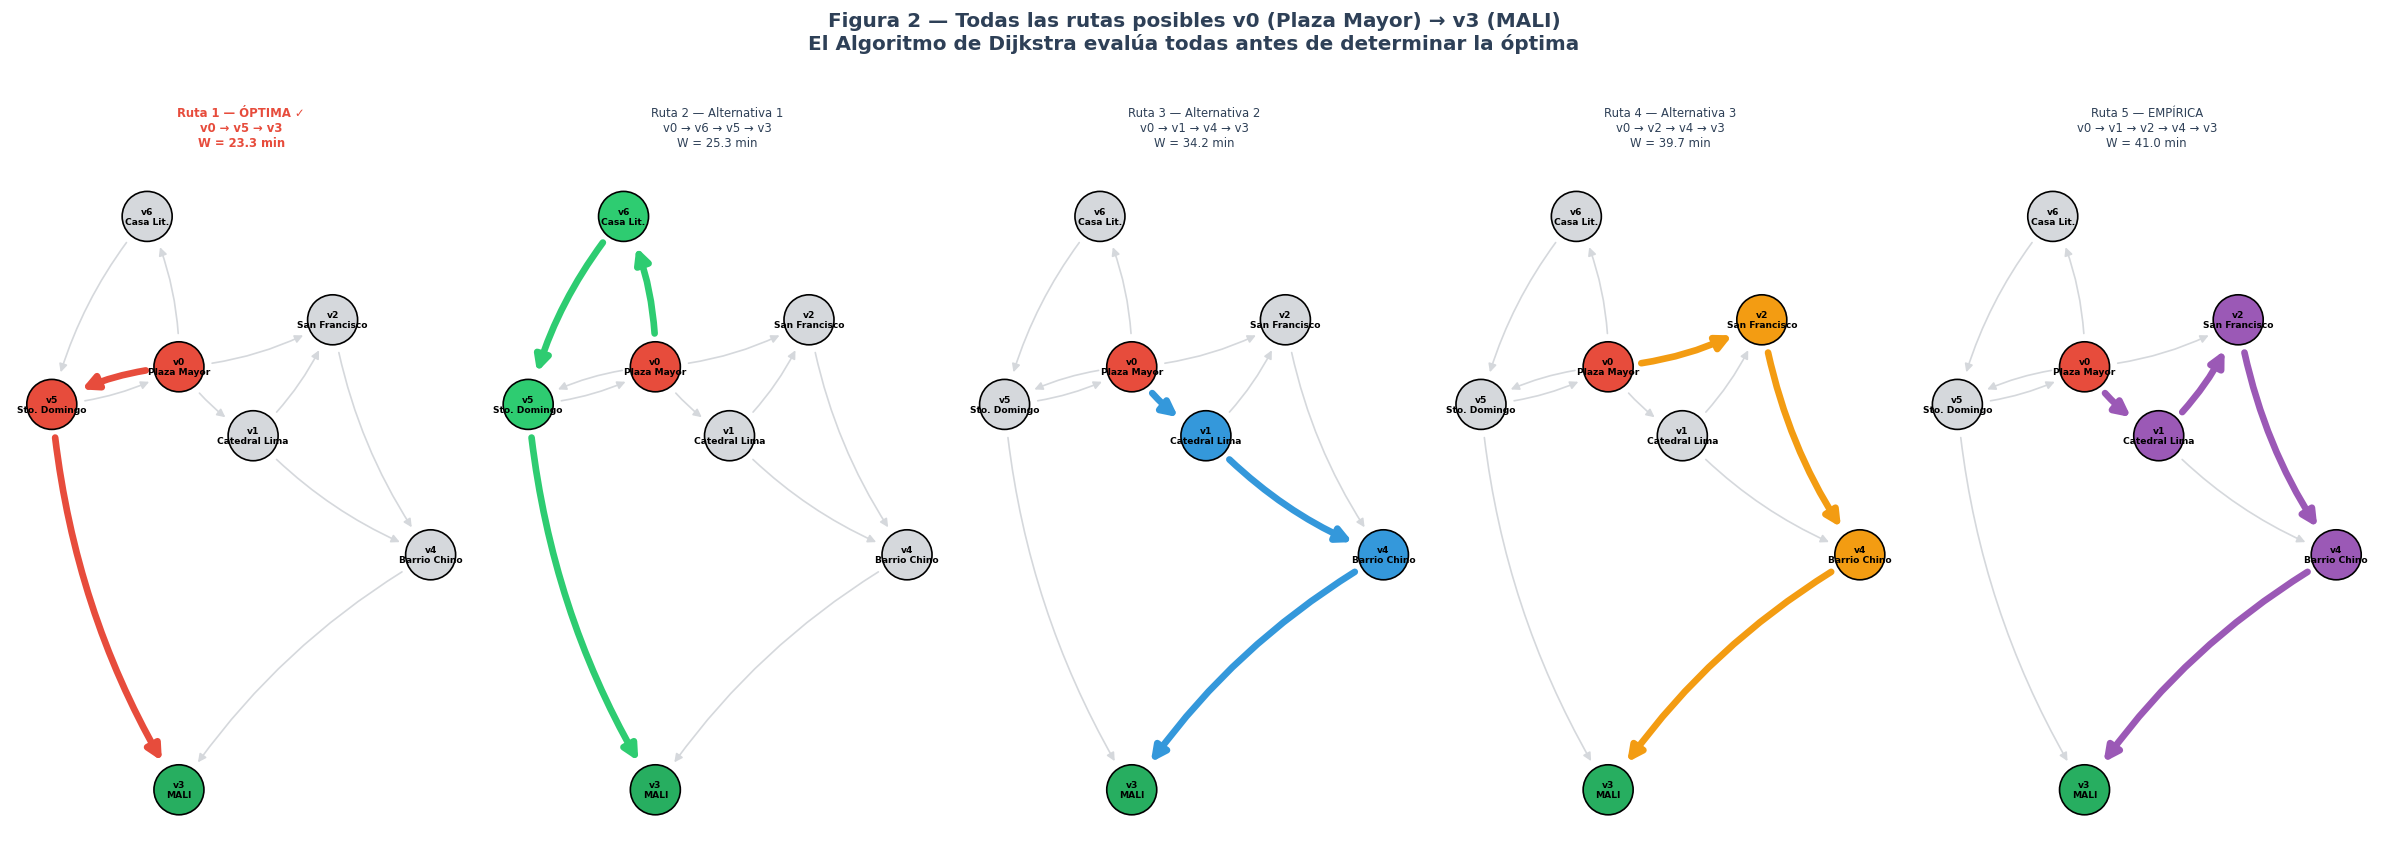

Figura 2 guardada como: todas_rutas_CHL.png  (5 rutas visualizadas)


In [ ]:
# ── 6.3  Figura 2: Visualización de TODAS las rutas posibles ────────────────
colores_rutas = [
    "#E74C3C",  # Ruta 1 óptima – rojo
    "#2ECC71",  # Ruta 2 – verde
    "#3498DB",  # Ruta 3 empírica – azul
    "#F39C12",  # Ruta 4 – naranja
    "#9B59B6",  # Ruta 5 – morado
]

n_rutas = len(todas_rutas_con_costo)
fig, axes = plt.subplots(1, n_rutas, figsize=(4 * n_rutas, 7), dpi=120)

for idx, ((ruta, costo), ax_sub) in enumerate(zip(todas_rutas_con_costo, axes)):
    color = colores_rutas[idx % len(colores_rutas)]

    # Colorear nodos
    node_colors = []
    for n in G.nodes():
        if n == ruta[0]:   node_colors.append("#E74C3C")
        elif n == ruta[-1]: node_colors.append("#27AE60")
        elif n in ruta:     node_colors.append(color)
        else:               node_colors.append("#D5D8DC")

    # Aristas de esta ruta
    aristas_ruta = set(zip(ruta, ruta[1:]))
    e_ruta  = [(u, v) for u, v in G.edges() if (u, v) in aristas_ruta]
    e_otros = [(u, v) for u, v in G.edges() if (u, v) not in aristas_ruta]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900,
                           edgecolors="black", linewidths=1.0, ax=ax_sub)
    nx.draw_networkx_labels(G, pos,
                            labels={n: f"{n}\n{nodos[n]}" for n in G.nodes()},
                            font_size=5.5, font_weight="bold", ax=ax_sub)
    nx.draw_networkx_edges(G, pos, edgelist=e_otros,
                           edge_color="#D5D8DC", width=1.0, arrows=True, arrowsize=10,
                           connectionstyle="arc3,rad=0.12", ax=ax_sub,
                           min_source_margin=20, min_target_margin=20)
    nx.draw_networkx_edges(G, pos, edgelist=e_ruta,
                           edge_color=color, width=4.0, arrows=True, arrowsize=18,
                           connectionstyle="arc3,rad=0.12", ax=ax_sub,
                           min_source_margin=20, min_target_margin=20)

    tipo = "ÓPTIMA ✓" if idx == 0 else ("EMPÍRICA" if costo == tiempo_empirico else f"Alternativa {idx}")
    ax_sub.set_title(
        f"Ruta {idx+1} — {tipo}\n" +
        " → ".join(ruta) + f"\nW = {costo:.1f} min",
        fontsize=7, fontweight="bold" if idx == 0 else "normal",
        color="#E74C3C" if idx == 0 else "#2E4057"
    )
    ax_sub.axis("off")

fig.suptitle(
    "Figura 2 — Todas las rutas posibles v0 (Plaza Mayor) → v3 (MALI)\n"
    "El Algoritmo de Dijkstra evalúa todas antes de determinar la óptima",
    fontsize=12, fontweight="bold", color="#2E4057", y=1.02
)
plt.tight_layout()
plt.savefig("todas_rutas_CHL.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura 2 guardada como: todas_rutas_CHL.png  ({n_rutas} rutas visualizadas)")


---
## Referencias bibliográficas

- Arnberger, A., & Brandenburg, C. (2007). *Environmental Management, 40*(1), 34–45. https://doi.org/10.1007/s00267-006-0068-y
- Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2022). *Introduction to algorithms* (4.ª ed.). MIT Press.
- Diestel, R. (2017). *Graph theory* (5.ª ed.). Springer.
- Dijkstra, E. W. (1959). A note on two problems in connexion with graphs. *Numerische Mathematik, 1*(1), 269–271.
- Gross, J. L., & Yellen, J. (2006). *Graph theory and its applications* (2.ª ed.). Chapman & Hall/CRC.
- Hagberg, A. A., Schult, D. A., & Swart, P. J. (2008). Proc. *SciPy 2008*, pp. 11–15.
- MINCETUR. (2024a). *Plan Estratégico Nacional de Turismo 2024–2030*. https://www.mincetur.gob.pe
- MINCETUR. (2024b). *Estadísticas de turismo receptivo 2023*. https://www.mincetur.gob.pe
- MINCUL. (2024). *Registro de monumentos y museos del CHL*. https://www.cultura.gob.pe
- Municipalidad de Lima. (2021). *Portal de datos abiertos – Turismo CHL*. https://datosabiertos.munlima.gob.pe
- Nielsen, J. (1994). *Usability engineering*. Academic Press.
- PromPerú. (2024). *Perfil del turista extranjero – CHL 2023*. https://www.promperu.gob.pe
- Riti, Y. F., Iskandar, J. S., & Hendra, H. (2023). *JITTER, 9*(2), 210–219.
- Transportation Research Board [TRB]. (2010). *Highway capacity manual* (5.ª ed.). National Academies.
- UNESCO. (1988). *Historic centre of Lima – World Heritage List*. https://whc.unesco.org/en/list/500
